# Hito 3 — Comparación de modelos y predicción futura

Se comparan visualmente los tres modelos entrenados, se realiza una predicción
autorregresiva de 365 días con el BiLSTM, y se comparan los modelos propios
con implementaciones externas de Hugging Face (mltrev23/gold-price-prediction).

- Se usa el BiLSTM como modelo final por ser el mejor de los propios
- La predicción autorregresiva actualiza la ventana en cada paso con la predicción anterior
- Las predicciones futuras deben interpretarse con cautela: no incorporan variables
  exógenas y no pueden anticipar eventos imprevistos de mercado

Scripts que se han ejecutado:
- Carga los modelos de `datasets/models/`

# Importar librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import joblib

from tensorflow.keras.models import load_model

# Cargar resultados

In [25]:
mlp = pd.read_csv("../datasets/models/mlp_results.csv")
lstm = pd.read_csv("../datasets/models/lstm_results.csv")
bilstm = pd.read_csv("../datasets/models/bilstm_results.csv")

dates_test = np.load("../datasets/train_test/dates_test.npy", allow_pickle=True)

mlp["date"] = pd.to_datetime(dates_test)
lstm["date"] = pd.to_datetime(dates_test)
bilstm["date"] = pd.to_datetime(dates_test)

data_scaled = joblib.load("../datasets/train_test/data_scaled.pkl")
scaler = joblib.load("../datasets/train_test/scaler.pkl")

model_bilstm = load_model("../datasets/models/bilstm_model.keras")
model_lstm = load_model("../datasets/models/lstm_model.keras")

# Gráfica

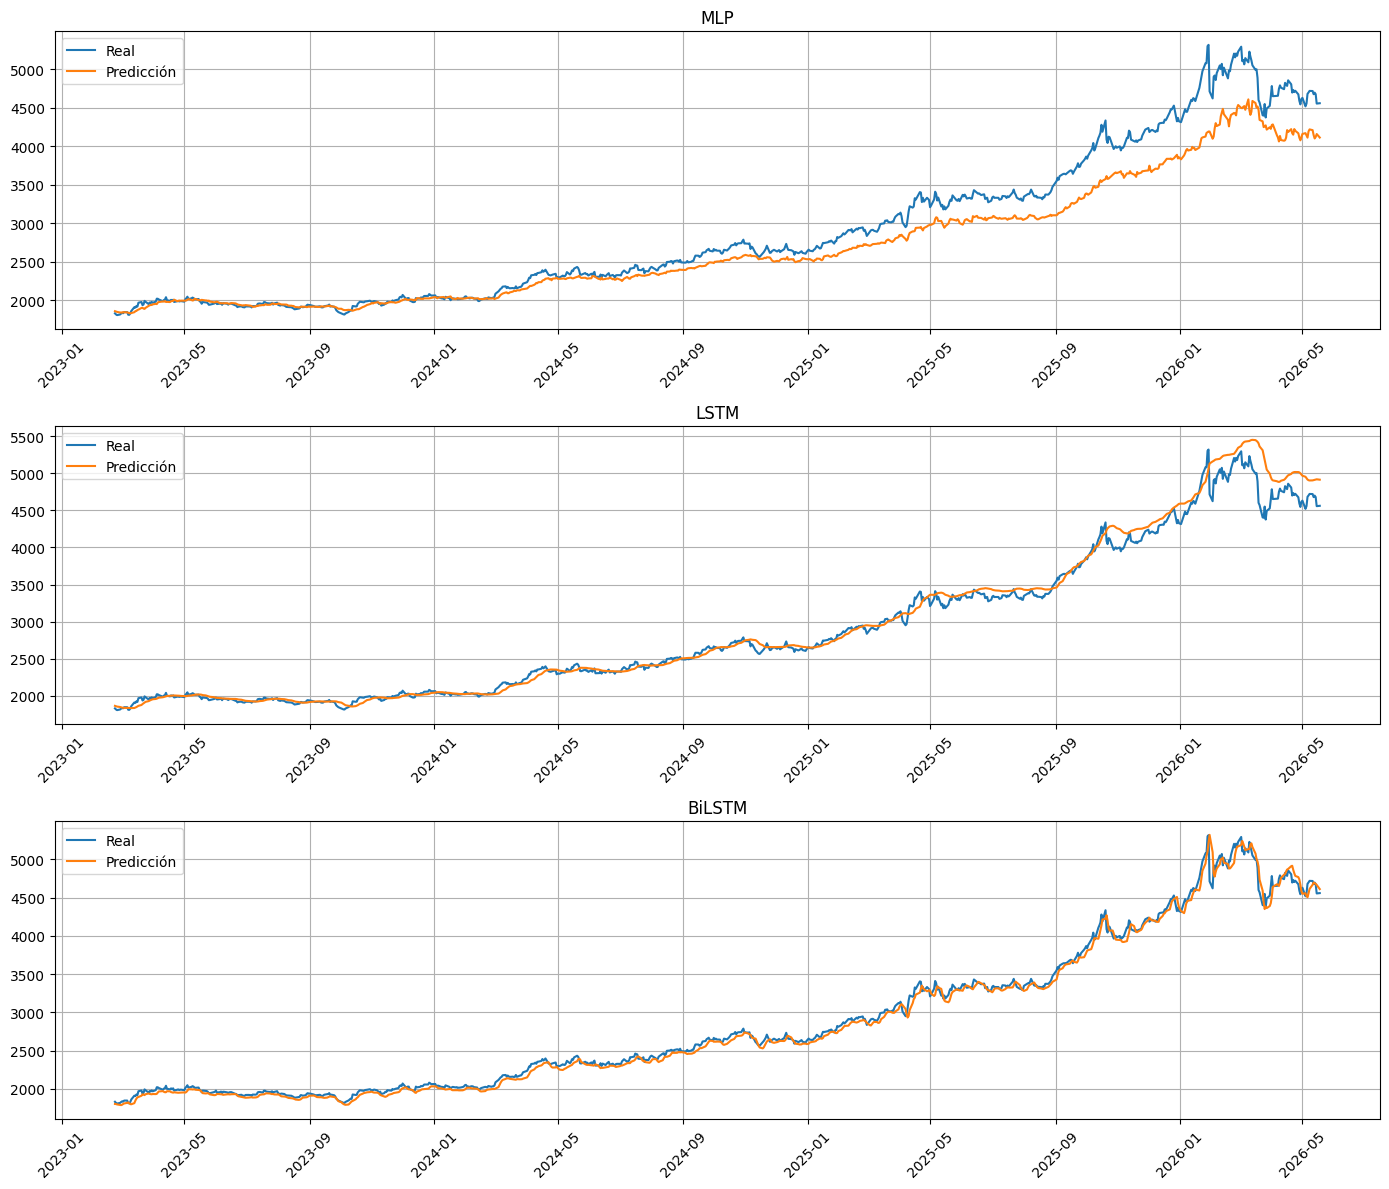

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

modelos = [
    ("MLP", mlp),
    ("LSTM", lstm),
    ("BiLSTM", bilstm)
]

for ax, (nombre, modelo_df) in zip(axes, modelos):
    ax.plot(modelo_df["date"], modelo_df["real"], label="Real")
    ax.plot(modelo_df["date"], modelo_df["pred"], label="Predicción")

    ax.set_title(nombre)
    ax.legend()
    ax.grid(True)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


- **Modelo MPL:**
Es capaz de seguir la tendencia general, pero tiene una mayor desviación respecto a los valores reales, sobretodo donde se experimentan cambios más bruscos, ya que tiene más dificultades para capturar la dependencia temporal de los datos.
- **Modelo LSTM:**
Este modelo consigue un ajuste mucho más preciso. Pues las predicciones siguen muy decerca la evolución real del precio del oro durante mucha parte del periodo analizado.
- **Modelo BiLSTM:**
Es el modelo con mejores resultados visuales tiene, ya que la línea de predicción prácticamente se superpone durante gran parte del periodo. Sin embargo, sigue habiendo una cierta diferencia en los momentos donde hay mayores picos.

A pesar de que todos los modelos han obtenido buenos resultados en las métricas de evaluación, la representación gráfica permite apreciar mejor las diferencias entre ellos. Los modelos LSTM y BiLSTM muestran una mayor capacidad para aprender la evolución temporal del precio del oro, mientras que el MLP presenta una mayor desviación en los cambios más pronunciados. Por ello, el modelo BiLSTM se considera la mejor opción para este proyecto, al ser el que consigue aproximarse con mayor precisión al comportamiento real de la serie temporal.

# Predicción del próximo año

In [ ]:
future_days = 365

# Últimos 30 días del dataset
last_sequence = data_scaled[-30:]

future_predictions = []

current_sequence = last_sequence.copy()

for _ in range(future_days):

    # Formato que espera LSTM/BiLSTM
    X_input = current_sequence.reshape(1, 30, 1)

    # Predicción
    pred = model_bilstm.predict(X_input, verbose=0)

    # Guardar resultado
    future_predictions.append(pred[0, 0])

    # Actualizar ventana
    current_sequence = np.vstack([
        current_sequence[1:],
        pred
    ])

# Volver a USD
future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1, 1)
)

print("Predicción próximos 365 días:")
print(future_predictions)

Predicción próximos 7 días:
[[4573.911 ]
 [4566.5117]
 [4570.1377]
 [4579.434 ]
 [4592.8413]
 [4607.573 ]
 [4618.8896]
 [4629.3804]
 [4637.676 ]
 [4640.3203]
 [4641.5903]
 [4643.878 ]
 [4643.007 ]
 [4640.883 ]
 [4635.96  ]
 [4631.017 ]
 [4628.61  ]
 [4628.5425]
 [4627.6265]
 [4628.638 ]
 [4636.66  ]
 [4646.8457]
 [4655.0854]
 [4662.989 ]
 [4668.6626]
 [4671.664 ]
 [4672.4365]
 [4668.6313]
 [4662.3145]
 [4658.1655]
 [4653.365 ]
 [4648.5454]
 [4644.8774]
 [4642.237 ]
 [4640.459 ]
 [4639.2314]
 [4638.208 ]
 [4637.1475]
 [4635.7305]
 [4633.761 ]
 [4631.237 ]
 [4628.0938]
 [4624.2515]
 [4619.8223]
 [4614.946 ]
 [4609.899 ]
 [4604.931 ]
 [4600.2344]
 [4596.021 ]
 [4592.591 ]
 [4590.077 ]
 [4588.3145]
 [4587.155 ]
 [4586.4795]
 [4586.0537]
 [4585.6924]
 [4585.2485]
 [4584.6416]
 [4583.9663]
 [4583.3345]
 [4582.761 ]
 [4582.373 ]
 [4582.2793]
 [4582.5317]
 [4583.148 ]
 [4584.112 ]
 [4585.3765]
 [4586.8696]
 [4588.505 ]
 [4590.1904]
 [4591.841 ]
 [4593.3745]
 [4594.725 ]
 [4595.8496]
 [4596.725

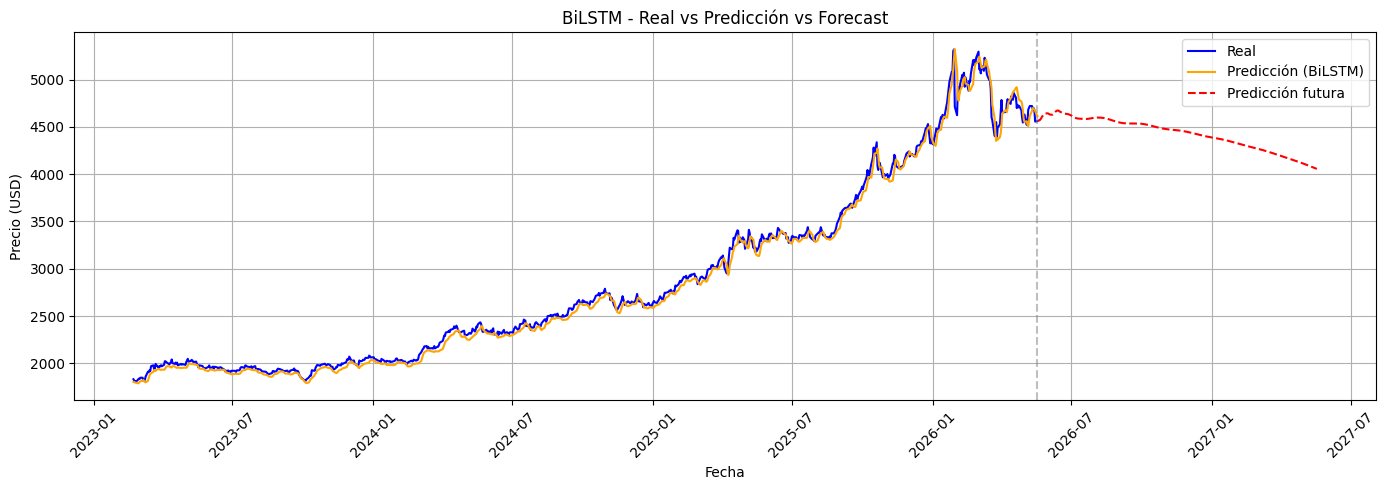

In [11]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(14, 5))

real = bilstm["real"].values
pred = bilstm["pred"].values
future = future_predictions

history_dates = bilstm["date"]
last_date = history_dates.iloc[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=len(future), freq="D")

# Real and predicted historical values
ax.plot(history_dates, real, label="Real", color="blue")
ax.plot(history_dates, pred, label="Predicción (BiLSTM)", color="orange")

# Forecast for the next days
ax.plot(future_dates, future, label="Predicción futura", color="red", linestyle="--")

ax.axvline(x=history_dates.iloc[-1], color="gray", linestyle="--", alpha=0.5)

ax.set_title("BiLSTM - Real vs Predicción vs Forecast")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio (USD)")
ax.legend()
ax.grid(True)
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


El modelo LSTM consigue captar la tendencia general del precio del oro, generando una predicción coherente y suavizada a lo largo del periodo analizado. Sin embargo, al compararlo con los valores reales, se observa que no reproduce completamente la volatilidad del mercado, ya que tiende a suavizar las fluctuaciones. Aun así, estos resultados deben interpretarse con cautela, ya que las predicciones en mercados financieros no son totalmente fiables y pueden verse alteradas en cualquier momento por factores externos o eventos económicos imprevistos que provoquen cambios bruscos en la demanda, como un aumento repentino en la compra de oro que haga variar significativamente su precio.

# Comparación con modelo de Hugging Face

In [ ]:
X_test = np.load("../datasets/train_test/X_test.npy")
y_test = np.load("../datasets/train_test/y_test.npy")

In [16]:
from huggingface_hub import hf_hub_download
import joblib

gru_model  = joblib.load(hf_hub_download("mltrev23/gold-price-prediction", "gru_gold_price_model.pkl"))
lstm_model = joblib.load(hf_hub_download("mltrev23/gold-price-prediction", "lstm_gold_price_model.pkl"))

gru_pred  = gru_model.predict(X_test)
lstm_pred = lstm_model.predict(X_test)

26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step


In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

def metricas(nombre, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return {"Modelo": nombre, "MAE": round(mae, 4), "RMSE": round(rmse, 4), "R²": round(r2, 4)}

tabla = pd.DataFrame([
    metricas("BiLSTM (propio)", y_test, model_bilstm.predict(X_test).flatten()),
    metricas("LSTM (propio)",  y_test, model_lstm.predict(X_test).flatten()), 
    metricas("LSTM (mltrev23)", y_test, lstm_pred),
    metricas("GRU (mltrev23)",  y_test, gru_pred),
])

print(tabla)

26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step
            Modelo     MAE    RMSE      R²
0  BiLSTM (propio)  0.0116  0.0159  0.9950
1    LSTM (propio)  0.0174  0.0301  0.9821
2  LSTM (mltrev23)  0.0282  0.0339  0.9774
3   GRU (mltrev23)  0.0077  0.0127  0.9968


Los cuatro modelos evaluados alcanzan un R² superior a 0.97, lo que confirma que todas las arquitecturas probadas son capaces de modelar con precisión la evolución del precio del oro.

El modelo GRU externo (mltrev23) obtiene las mejores métricas absolutas con un MAE de 0.0077 y un RMSE de 0.0127, siendo el más preciso de los cuatro. Sin embargo, el BiLSTM propio se sitúa como segundo mejor modelo con un MAE de 0.0116 y un R² de 0.9950, superando tanto al LSTM propio (MAE 0.0174, R² 0.9821) como al LSTM externo (MAE 0.0282, R² 0.9774).

La comparación entre los dos modelos propios revela que la arquitectura BiLSTM mejora al LSTM simple en todas las métricas, lo que justifica el uso de capas bidireccionales para esta tarea: el procesamiento de la secuencia en ambas direcciones permite capturar dependencias temporales que el LSTM unidireccional no llega a detectar.

Respecto a los modelos externos, el GRU de mltrev23 supera al BiLSTM propio en error absoluto, aunque por un margen reducido, mientras que su LSTM queda por debajo de ambos modelos propios. Esto indica que la arquitectura GRU resulta especialmente eficiente para este problema, y que el trabajo de preprocesamiento y entrenamiento aplicado en este proyecto produce resultados comparables e incluso superiores a implementaciones públicas de referencia.